In [1]:
import numpy as np
from votekit.cvr_loaders import load_scottish
import matplotlib.pyplot as plt
import votekit.ballot_generator as bg
from votekit.plots import plot_MDS, compute_MDS
from votekit import PreferenceInterval
from votekit.metrics import lp_dist
import pickle

# used to import local files
import sys  
sys.path.insert(1, './')

from optimize_helper import *


plt.rcParams['text.usetex'] = True
SMALL_SIZE = 16
MEDIUM_SIZE = 20
BIGGER_SIZE = 24

plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=MEDIUM_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=SMALL_SIZE)    # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title

In [2]:
b_bloc_parties = ['Scottish National Party (SNP)', 'Green (Gr)']
file_names = {("fife", 2022, 21): "../election_data/fife_2022_ward21.csv",
              ("aberdeen", 2017, 12) : "../election_data/aberdeen_2017_ward12.csv",
              ("aberdeen", 2022, 12): "../election_data/aberdeen_2022_ward12.csv",
              ("angus", 2012, 8): "../election_data/angus_2012_ward8.csv",
              ("falkirk", 2017, 6): "../election_data/falkirk_2017_ward6.csv",
              ("clackmannanshire", 2012, 2): "../election_data/clackmannanshire_2012_ward2.csv",
              ("renfrewshire", 2017, 1): "../election_data/renfrewshire_2017_ward1.csv",
              ("glasgow", 2012, 16): "../election_data/glasgow_2012_ward16.csv",
              ("north-ayrshire", 2022, 1): "../election_data/north_ayrshire_2022_north_coast.csv"
              }


models_to_gen = {"n-BT": bg.name_BradleyTerry,
            "n-PL": bg.name_PlackettLuce,
            "s-BT": bg.slate_BradleyTerry,
            "s-PL": bg.slate_PlackettLuce,
            "CS-C": bg.CambridgeSampler,
            "CS-W": bg.CambridgeSampler,
            "SB": 0,
            "IC":bg.ImpartialCulture,
            "IAC": bg.ImpartialAnonymousCulture}

new_models = ["CS-C", "CS-W", "n-BT", "n-PL", "s-BT", "s-PL"]
old_models = ["SB", "IC", "IAC"]
scottish_color = ["#1560BD"]
model_to_color = {'CS-C': '#D2691E', 'CS-W': '#E32636', 'n-BT': '#8B008B', 'n-PL': '#FFB7C5', 's-BT': '#FFBF00', 's-PL': '#8DB600',"SB":"#09FCEE", "IC":"#1A7601",
                      "IAC":"#929292" }

# Generate profiles from optimal settings

In [10]:
bloc_order = "AB"
stat = "WD"
MCMC_sample_size = 10000

# save each ward
ward_to_profile={}
for key, file_name in file_names.items():
    city, year, ward = key

    # too many cands to do IC,IAC
    if city in ["glasgow", "north-ayrshire"]:
        temp_old_models = ["SB"]
    else: 
        temp_old_models = ["SB", "IC", "IAC"]
    
    ward_label = f"{city} ward_{ward} {year}"
    print(ward_label)

    # estimate model parameters
    model_parameters = estimate_1_bloc_parameters(file_name, b_bloc_parties)

    scottish_profile, num_seats, cand_list, cand_to_party, ward = load_scottish(file_name)
    cand_to_bloc = {c:"B" if cand_to_party[c] in b_bloc_parties 
                else "A" for c in cand_list}
    
    # count the number of candidates in each bloc
    bloc_to_cand_num = {"A": len([c for c, bloc in cand_to_bloc.items() if bloc == "A"]),
                        "B": len([c for c, bloc in cand_to_bloc.items() if bloc == "B"])}
    slate_to_candidates = {b: [f"{b}_{i}" for i in range(bloc_to_cand_num[b])] for b in bloc_to_cand_num.keys()}
    cand_to_bloc = {c:b for b,c_list in slate_to_candidates.items() for c in c_list}

    # only looking at B bloc
    bloc_voter_prop = {"A": 0, "B": 1}

    profile_lists = {}
    model_list = temp_old_models+new_models
    for model_str in model_list:
        print(model_str)
        with open(f"distance_data/1_bloc/distance_to_solid_{ward_label}_one_bloc_optimized_{stat}_{model_str}_bloc_order_{bloc_order}_b_bloc_parties_{b_bloc_parties}.pickle", "rb") as f:
            min_pi_b, opt_distances = pickle.load(f)
        
            # A bloc does not matter here
            if isinstance(min_pi_b, float):
                cohesion_parameters = {"A": {"A": 1, "B": 0},
                                        "B": {"B": min_pi_b, 
                                            "A": 1-min_pi_b}}
            
            # these are arbitrary; if slate model, ballot type not determined by PrefInt
            # if name model, we use estimated PrefInt
            alphas = {"A": {"A": 1, "B": 1},
                        "B": {"B": 1, "A": 1}}
            
            if model_str not in ["n-BT", "n-PL", "SB", "IC", "IAC"]:
                if "CS" in model_str:
                    if model_str == "CS-W":
                        bg = models_to_gen[model_str].from_params(slate_to_candidates, 
                                    bloc_voter_prop, 
                                    cohesion_parameters, 
                                    alphas,
                                    W_bloc = "B",
                                    C_bloc = "A")
                    else:
                        bg = models_to_gen[model_str].from_params(slate_to_candidates, 
                                    bloc_voter_prop, 
                                    cohesion_parameters, 
                                    alphas,
                                    W_bloc = "A",
                                    C_bloc = "B")
                else:
                    bg = models_to_gen[model_str].from_params(slate_to_candidates, 
                                    bloc_voter_prop, 
                                    cohesion_parameters, 
                                    alphas)
            elif model_str not in old_models:
                candidates = []
                for c_list in slate_to_candidates.values():
                    candidates += c_list

                ba_interval = {f"A_{i}":p for i, p in enumerate(model_parameters["pref_intervals"]["A"].values())}
                bb_interval = {f"B_{i}":p for i, p in enumerate(model_parameters["pref_intervals"]["B"].values())}

                # A pref intervals don't matter because only looking at B bloc voters
                pref_intervals_by_bloc = {"A": {"A": PreferenceInterval({c: 1/len(slate_to_candidates["A"]) for c in slate_to_candidates["A"]}),
                                                "B": PreferenceInterval({c: 1/len(slate_to_candidates["B"]) for c in slate_to_candidates["B"]})},
                                        "B": {"A" : PreferenceInterval(ba_interval),
                                                "B" : PreferenceInterval(bb_interval)}
                                        }
                bg = models_to_gen[model_str](candidates = candidates, cohesion_parameters = cohesion_parameters, bloc_voter_prop = bloc_voter_prop,
                        pref_intervals_by_bloc = pref_intervals_by_bloc)

            elif model_str in ["IC", "IAC"]:
                bg = models_to_gen[model_str](candidates = list(cand_to_bloc.keys()))
            
            else:
                pass
            
            # generate 10 profiles
            profiles = [-1]*10
            for i in range(10):
                # use MCMC sampling if cannot compute PDF
                if sum(bloc_to_cand_num.values()) >= 12 and "BT" in model_str:
                    if model_str == "n-BT":
                        profile  = bg.generate_profile_MCMC(MCMC_sample_size)
                    else:
                        profile  = bg.generate_profile(MCMC_sample_size, deterministic=False)
                        
                elif model_str == "SB":
                    # generate SB is deterministic, at least at the moment
                    profile = generate_solid_profile(min_pi_b, int(scottish_profile.num_ballots()), bloc_to_cand_num)
                else:
                    profile  = bg.generate_profile(int(scottish_profile.num_ballots()))
                
                profiles[i] = profile
        
        profile_lists[model_str]=profiles
    ward_to_profile[ward_label] = profile_lists

fife ward_21 2022
SB
IC
IAC
CS-C
CS-W
n-BT
n-PL
s-BT
s-PL
aberdeen ward_12 2017
SB
IC
IAC
CS-C
CS-W
n-BT
n-PL
s-BT
s-PL
aberdeen ward_12 2022
SB
IC
IAC
CS-C
CS-W
n-BT
n-PL
s-BT
s-PL
angus ward_8 2012
SB
IC
IAC
CS-C
CS-W
n-BT
n-PL
s-BT
s-PL
falkirk ward_6 2017
SB
IC
IAC
CS-C
CS-W
n-BT
n-PL
s-BT
s-PL
clackmannanshire ward_2 2012
SB
IC
IAC
CS-C
CS-W
n-BT
n-PL
s-BT
s-PL
renfrewshire ward_1 2017
SB
IC
IAC
CS-C
CS-W
n-BT
n-PL
s-BT
s-PL
glasgow ward_16 2012
SB
CS-C
CS-W
n-BT


/Users/cdonnay/Dropbox/OSU/Year_4/MGGG/RCV Moon Thomas/scottish_elec/.venv/lib/python3.11/site-packages/votekit/ballot_generator.py:703: UserWarning: For 12 or more candidates, exact sampling is computationally infeasible.                     Please only use the built in generate_profile_MCMC method.
  warnings.warn(


n-PL
s-BT


/Users/cdonnay/Dropbox/OSU/Year_4/MGGG/RCV Moon Thomas/scottish_elec/.venv/lib/python3.11/site-packages/votekit/ballot_generator.py:1735: UserWarning: For 12 or more candidates, exact sampling is computationally infeasible.                     Please set deterministic = False when calling generate_profile.
  warnings.warn(


s-PL
north-ayrshire ward_1 2022
SB
CS-C
CS-W
n-BT
n-PL
s-BT
s-PL


# Compute MDS coords
Took 24 min for a 10 cand election with 6 profiles per method.

In [15]:
ward_to_coords = {}
for key, file_name in [(("aberdeen", 2017, 12), "../election_data/aberdeen_2017_ward12.csv")]:
    city, year, ward = key

    if city in ["glasgow", "north-ayrshire"]:
        temp_old_models = ["SB"]
    else: 
        temp_old_models = ["SB", "IC", "IAC"]
    
    ward_label = f"{city} ward_{ward} {year}"
    print(ward_label)
    scottish_profile = load_scottish(file_name)[0]
    # the data is a dictionary whose keys correspond to data labels
    # and whose values are lists of PreferenceProfiles
    data =  {model_str:profiles[:6] for model_str, profiles in ward_to_profile[ward_label].items()}
    data.update({"scottish":[scottish_profile]})
    coord_dict = compute_MDS(data =data, 
                            distance = lp_dist, random_seed=47)
    
    print(coord_dict)
    print()

    ward_to_coords[ward_label]=coord_dict
    




aberdeen ward_12 2017
{'SB': (array([-0.1645724, -0.1645724, -0.1645724, -0.1645724, -0.1645724,
       -0.1645724]), array([-1.32133408, -1.32133408, -1.32133408, -1.32133408, -1.32133408,
       -1.32133408])), 'IC': (array([-0.76072696, -0.36562745,  1.49842402,  0.82978821, -0.1594886 ,
       -0.39975204]), array([-0.80278054, -0.44441442, -0.23774217, -1.28452649,  1.4949516 ,
        1.10043798])), 'IAC': (array([-0.4623403 ,  1.433481  , -0.15735451,  1.18572372, -0.87384947,
       -0.07136979]), array([ 1.44160349, -0.52281302,  0.00621552, -1.01248346, -1.22698527,
        0.96592064])), 'CS-C': (array([-1.37518812, -1.11726575, -1.18891142, -0.9314967 , -1.44345326,
       -1.40541764]), array([-0.1147561 , -0.02506283, -0.36862439, -0.16822892,  0.05669087,
       -0.31324434])), 'CS-W': (array([-1.14193195, -1.24323437, -0.98373158, -1.24849214, -1.0396338 ,
       -0.89299226]), array([0.82372751, 0.68821029, 0.84085976, 0.54151277, 0.55527475,
       0.6439618 ])), 'n-B

# Plot MDS

aberdeen ward_12 2017


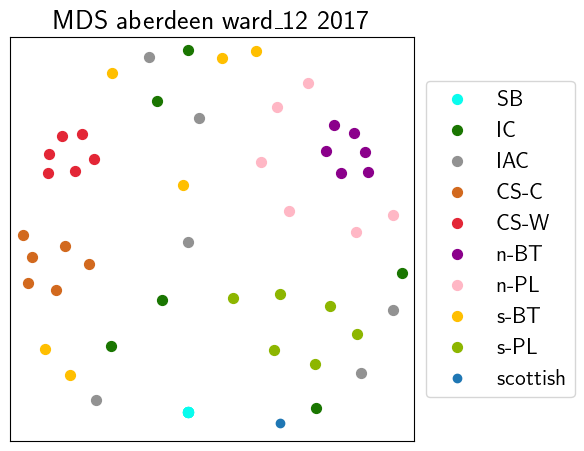

<Figure size 640x480 with 0 Axes>

In [16]:
for key, file_name in [(("aberdeen", 2017, 12), "../election_data/aberdeen_2017_ward12.csv")]:
    city, year, ward = key

    if city in ["glasgow", "north-ayrshire"]:
        temp_old_models = ["SB"]
    else: 
        temp_old_models = ["SB", "IC", "IAC"]
    
    ward_label = f"{city} ward_{ward} {year}"
    print(ward_label)
    plot_kwarg_dict={m:{"c":color, "s":50} for m, color in model_to_color.items()}
    plot_kwarg_dict.update({ward_label: {"c": scottish_color, "s":50}})
    
    ax = plot_MDS(coord_dict=ward_to_coords[ward_label], 
                    plot_kwarg_dict=plot_kwarg_dict,
                    legend = True, title = True)
    
    ax.legend(bbox_to_anchor=(1, .5), loc="center left")
    plt.title(f"MDS {ward_label}")
    plt.tight_layout()
    plt.show()
    # plt.savefig(f"figures/MDS/mds_{ward_label}_opt_profiles.png",bbox_inches='tight', dpi=300)
    plt.clf()